In [1]:
%pip install captum
!git clone https://github.com/kapitan05/causal_calibration.git
%cd causal_calibration
%mkdir -p data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.1 MB/s eta 0:00:00
Cloning into 'causal_calibration'...
remote: Enumerating objects: 197, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 197 (delta 18), reused 29 (delta 10), pack-reused 157 (from 1)
Receiving objects: 100% (197/197), 69.42 MiB | 33.16 MiB/s, done.
Resolving deltas: 100% (120/120), done.
/content/causal_calibration


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
import random

import torch.nn as nn
import torchvision.models as models
from torchvision import transforms

from datasets import load_dataset, Image as HFImage
from google.colab import userdata

from src.models import get_preprocessing_transforms
from src.attribution import AttributionPipeline
from src.causal_tests import evaluate_causal_metric
from src.calibration import ReCalXModel, temperature_scaling
from src.generators import BucketDeletionGenerator, TopNDeletionGenerator
from src.metrics import calculate_ece, calculate_tace

In [3]:
def normalize_saliency(sal: np.ndarray) -> np.ndarray:
    sal = np.maximum(sal, 0)
    return (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)

def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(img * std + mean, 0, 1)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Raw logits — required for temperature scaling and ReCalXModel
raw_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device).eval()
for p in raw_model.parameters():
    p.requires_grad = False

# With softmax — used only for top-1 class selection
model_softmax = nn.Sequential(raw_model, nn.Softmax(dim=1)).eval()

def get_top1(tensor: torch.Tensor) -> int:
    with torch.no_grad():
        return int(torch.argmax(model_softmax(tensor.to(device))).item())

print("ResNet50 loaded.")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 114MB/s]


ResNet50 loaded.


In [5]:
# Same code path used by collect_logits_for_calibration in src/calibration.py
pipeline = AttributionPipeline(raw_model)
print("AttributionPipeline ready.")

Generating filters: 100%|██████████| 5000/5000 [00:23<00:00, 216.00it/s]


AttributionPipeline ready.


In [7]:
k = userdata.get("HF_TOKEN")
!wget -q --header="Authorization: Bearer {k}" \
  "https://huggingface.co/datasets/ILSVRC/imagenet-1k/resolve/main/data/train-00000-of-00294.parquet"

hf_dataset = load_dataset("parquet", data_files="train-00000-of-00294.parquet", split="train")
hf_dataset = hf_dataset.cast_column("image", HFImage())
print(f"Loaded {len(hf_dataset)} images.")

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 4358 images.


In [8]:
SEED = 42
random.seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)

preprocess = get_preprocessing_transforms()
indices  = random.sample(range(len(hf_dataset)), 20)
selected = hf_dataset.select(indices)

samples = []
for item in tqdm(selected, desc="Loading images"):
    pil_img = item["image"].convert("RGB")
    tensor  = preprocess(pil_img).unsqueeze(0)   # (1, 3, 224, 224)
    samples.append((pil_img, tensor))

img_batch      = torch.cat([t for _, t in samples], dim=0)   # (20, 3, 224, 224)
target_classes = [get_top1(t) for _, t in samples]

print(f"img_batch: {img_batch.shape}")
print(f"Target classes: {target_classes}")

Loading images: 100%|██████████| 20/20 [00:00<00:00, 81.74it/s]


img_batch: torch.Size([20, 3, 224, 224])
Target classes: [194, 871, 106, 88, 578, 975, 207, 665, 669, 234, 726, 118, 920, 138, 944, 717, 715, 455, 9, 796]


In [9]:
rise_sals = []
for i, (_, tensor) in enumerate(tqdm(samples, desc="RISE saliency")):
    sal = pipeline.generate_map(tensor, target_classes[i], "rise").numpy()  # (224, 224)
    rise_sals.append(sal)

rise_sal_batch = np.stack(rise_sals)   # (20, 224, 224)
print(f"rise_sal_batch: {rise_sal_batch.shape}")

RISE saliency: 100%|██████████| 20/20 [05:08<00:00, 15.42s/it]

rise_sal_batch: (20, 224, 224)


## Section 2 — Single Image Deep-Dive

Walk through one image in detail: build a deletion sequence, run both the raw and calibrated model, and inspect the fitted temperatures and confidence curves.

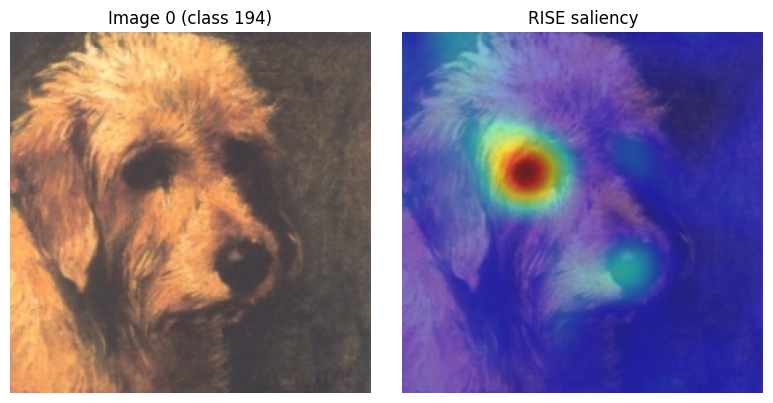

Sequence shape : torch.Size([26, 3, 224, 224])
Levels (first5): ['0.00', '0.04', '0.08', '0.12', '0.16'] ...


In [10]:
IMG_IDX      = 0
single_tensor = img_batch[IMG_IDX:IMG_IDX+1]   # (1, 3, 224, 224)
target_class  = target_classes[IMG_IDX]

sal_norm   = normalize_saliency(rise_sals[IMG_IDX])   # [0, 1]
sal_tensor = torch.from_numpy(sal_norm)

gen_del = BucketDeletionGenerator(num_buckets=25)
seq_del, lvl_del = gen_del(single_tensor.cpu(), sal_tensor)

# Visualise original image + saliency overlay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(denormalize(single_tensor)); ax1.axis("off"); ax1.set_title(f"Image {IMG_IDX} (class {target_class})")
ax2.imshow(denormalize(single_tensor))
ax2.imshow(sal_norm, cmap="jet", alpha=0.5); ax2.axis("off"); ax2.set_title("RISE saliency")
plt.tight_layout(); plt.show()

print(f"Sequence shape : {seq_del.shape}")
print(f"Levels (first5): {[f'{l:.2f}' for l in lvl_del[:5]]} ...")

In [11]:
raw_probs, raw_auc, raw_all_probs = evaluate_causal_metric(
    raw_model, seq_del.to(device), lvl_del, target_class
)
print(f"Raw model | AUC: {raw_auc:.4f} | Initial confidence: {raw_probs[0]:.4f}")

Raw model | AUC: 0.0363 | Initial confidence: 0.5124


In [12]:
NUM_BINS = 10

logits_bins = {b: [] for b in range(NUM_BINS)}
labels_bins = {b: [] for b in range(NUM_BINS)}

with torch.no_grad():
    raw_logits_all = raw_model(seq_del.to(device)).cpu().numpy()   # (26, 1000)

for step_idx, logits in enumerate(raw_logits_all):
    level   = lvl_del[step_idx]
    bin_idx = min(int(level * NUM_BINS), NUM_BINS - 1)
    logits_bins[bin_idx].append(logits)
    labels_bins[bin_idx].append(target_class)

learned_temps_single = []
for b in range(NUM_BINS):
    lgt = logits_bins[b]
    lbl = labels_bins[b]
    if len(lgt) > 1:
        T = temperature_scaling(np.stack(lgt), np.array(lbl, dtype=np.int64))
    else:
        T = 1.0
    learned_temps_single.append(round(T, 4))

print(f"{'Bin':>4}  {'Level range':>12}  {'Samples':>8}  {'T':>8}")
print("-" * 40)
for b, T in enumerate(learned_temps_single):
    lo, hi = b / NUM_BINS, (b + 1) / NUM_BINS
    n = len(logits_bins[b])
    print(f"{b:>4}  {lo:.1f}–{hi:.1f}        {n:>8}  {T:>8.4f}")

 Bin   Level range   Samples         T
----------------------------------------
   0  0.0–0.1               3    0.0500
   1  0.1–0.2               3    0.4675
   2  0.2–0.3               2    0.9462
   3  0.3–0.4               3    1.2368
   4  0.4–0.5               2    1.1789
   5  0.5–0.6               3    1.5909
   6  0.6–0.7               2    2.0223
   7  0.7–0.8               3    5.0000
   8  0.8–0.9               2    5.0000
   9  0.9–1.0               3    5.0000


In [14]:
recalx_single = ReCalXModel(raw_model, num_bins=NUM_BINS)
recalx_single.load_learned_temperatures(learned_temps_single)
recalx_single = recalx_single.to(device)
cal_probs, cal_auc, cal_all_probs = evaluate_causal_metric(
    recalx_single, seq_del.to(device), lvl_del, target_class
)
print(f"Calibrated model | AUC: {cal_auc:.4f} | Initial confidence: {cal_probs[0]:.4f}")

Calibrated model | AUC: 0.1199 | Initial confidence: 1.0000


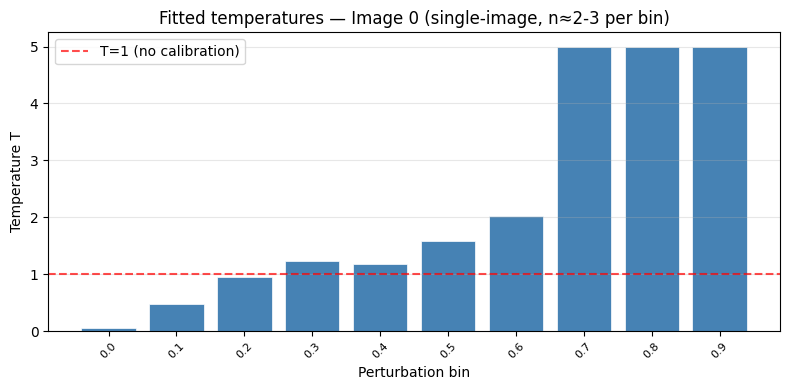

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
bins_x = np.arange(NUM_BINS)
ax.bar(bins_x, learned_temps_single, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1 (no calibration)")
ax.set_xlabel("Perturbation bin")
ax.set_ylabel("Temperature T")
ax.set_title(f"Fitted temperatures — Image {IMG_IDX} (single-image, n≈2-3 per bin)")
ax.set_xticks(bins_x)
ax.set_xticklabels([f"{b/NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

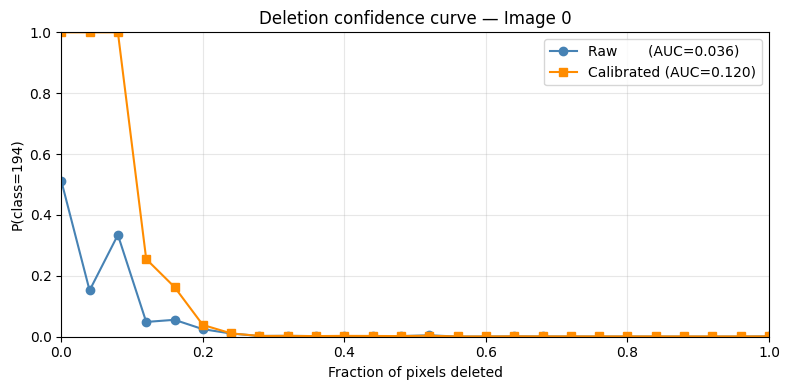

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lvl_del, raw_probs, "o-", color="steelblue",  label=f"Raw       (AUC={raw_auc:.3f})")
ax.plot(lvl_del, cal_probs, "s-", color="darkorange", label=f"Calibrated (AUC={cal_auc:.3f})")
ax.set_xlabel("Fraction of pixels deleted")
ax.set_ylabel(f"P(class={target_class})")
ax.set_title(f"Deletion confidence curve — Image {IMG_IDX}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

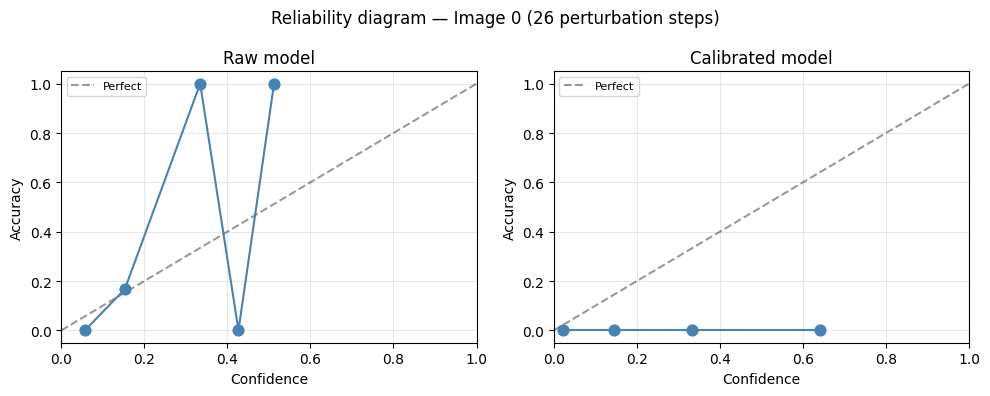

In [17]:
labels_single = np.full(len(lvl_del), target_class, dtype=np.int64)

def plot_reliability(ax, probs_np: np.ndarray, labels_np: np.ndarray, title: str) -> None:
    confs = np.max(probs_np, axis=1)
    preds = np.argmax(probs_np, axis=1)
    accs  = (preds == labels_np).astype(float)
    bins  = np.linspace(0, 1, 11)
    bin_confs, bin_accs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confs >= lo) & (confs < hi)
        if mask.sum() > 0:
            bin_confs.append(confs[mask].mean())
            bin_accs.append(accs[mask].mean())
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
    ax.scatter(bin_confs, bin_accs, color="steelblue", s=60, zorder=5)
    if bin_confs:
        ax.plot(bin_confs, bin_accs, color="steelblue")
    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_reliability(ax1, raw_all_probs, labels_single, "Raw model")
plot_reliability(ax2, cal_all_probs, labels_single, "Calibrated model")
plt.suptitle(f"Reliability diagram — Image {IMG_IDX} (26 perturbation steps)", fontsize=12)
plt.tight_layout(); plt.show()

In [18]:
ece_raw  = calculate_ece(raw_all_probs,  labels_single)
ece_cal  = calculate_ece(cal_all_probs,  labels_single)
tace_raw = calculate_tace(raw_all_probs, labels_single)
tace_cal = calculate_tace(cal_all_probs, labels_single)

print(f"{'Metric':<8} {'Raw':>10} {'Calibrated':>12} {'Delta':>10}")
print("-" * 44)
print(f"{'ECE':<8} {ece_raw:>10.4f} {ece_cal:>12.4f} {ece_cal - ece_raw:>+10.4f}")
print(f"{'TACE':<8} {tace_raw:>10.4f} {tace_cal:>12.4f} {tace_cal - tace_raw:>+10.4f}")
print("\nNegative delta = improvement (lower ECE/TACE is better)")
print("Note: single-image calibration overfits — Section 3 gives a more meaningful estimate.")

Metric          Raw   Calibrated      Delta
--------------------------------------------
ECE          0.1010       0.0813    -0.0197
TACE         0.1926       0.1375    -0.0550

Negative delta = improvement (lower ECE/TACE is better)
Note: single-image calibration overfits — Section 3 gives a more meaningful estimate.


## Section 3 — Batch Evaluation (20 images)

Fit temperatures from all 20 images jointly, then evaluate per-image ECE/TACE to compute mean ± std.

In [19]:
batch_logits_bins = {b: [] for b in range(NUM_BINS)}
batch_labels_bins = {b: [] for b in range(NUM_BINS)}

gen_del = BucketDeletionGenerator(num_buckets=25)

for i in tqdm(range(len(samples)), desc="Collecting logits"):
    tensor = img_batch[i:i+1]
    tc     = target_classes[i]
    sal    = torch.from_numpy(normalize_saliency(rise_sals[i]))

    seq_del_i, lvl_del_i = gen_del(tensor.cpu(), sal)

    with torch.no_grad():
        step_logits = raw_model(seq_del_i.to(device)).cpu().numpy()   # (26, 1000)

    for step_idx, logits in enumerate(step_logits):
        level   = lvl_del_i[step_idx]
        bin_idx = min(int(level * NUM_BINS), NUM_BINS - 1)
        batch_logits_bins[bin_idx].append(logits)
        batch_labels_bins[bin_idx].append(tc)

print(f"\n{'Bin':>4}  {'Level range':>12}  {'Samples':>8}")
print("-" * 30)
for b in range(NUM_BINS):
    lo, hi = b / NUM_BINS, (b + 1) / NUM_BINS
    print(f"{b:>4}  {lo:.1f}–{hi:.1f}        {len(batch_logits_bins[b]):>8}")


 Bin   Level range   Samples
------------------------------
   0  0.0–0.1              60
   1  0.1–0.2              60
   2  0.2–0.3              40
   3  0.3–0.4              60
   4  0.4–0.5              40
   5  0.5–0.6              60
   6  0.6–0.7              40
   7  0.7–0.8              60
   8  0.8–0.9              40
   9  0.9–1.0              60


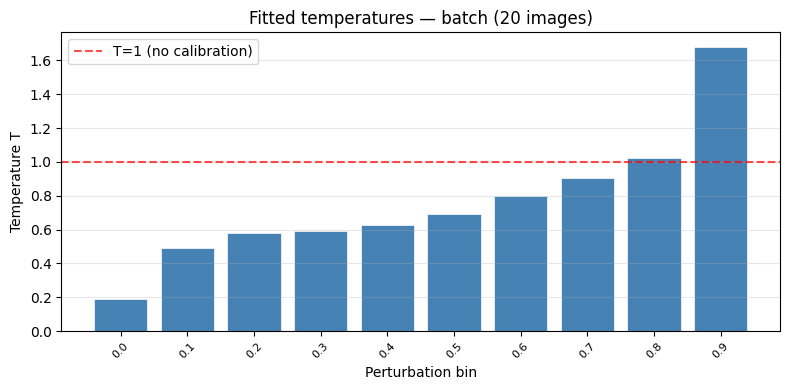

Temperatures: [0.1926, 0.4925, 0.5785, 0.5924, 0.6242, 0.6924, 0.7999, 0.9028, 1.022, 1.6815]


In [23]:
batch_temps = []
for b in range(NUM_BINS):
    lgt = batch_logits_bins[b]
    lbl = batch_labels_bins[b]
    if len(lgt) > 1:
        T = temperature_scaling(np.stack(lgt), np.array(lbl, dtype=np.int64))
    else:
        T = 1.0
    batch_temps.append(round(T, 4))

global_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS)
global_recalx.load_learned_temperatures(batch_temps)
global_recalx = global_recalx.to(device)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(NUM_BINS), batch_temps, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1 (no calibration)")
ax.set_xlabel("Perturbation bin")
ax.set_ylabel("Temperature T")
ax.set_title("Fitted temperatures — batch (20 images)")
ax.set_xticks(np.arange(NUM_BINS))
ax.set_xticklabels([f"{b/NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8)
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

print("Temperatures:", batch_temps)

In [24]:
ece_raws, ece_cals   = [], []
tace_raws, tace_cals = [], []

for i in tqdm(range(len(samples)), desc="Evaluating images"):
    tensor = img_batch[i:i+1]
    tc     = target_classes[i]
    sal    = torch.from_numpy(normalize_saliency(rise_sals[i]))

    seq_del_i, lvl_del_i = gen_del(tensor.cpu(), sal)
    labels_i = np.full(len(lvl_del_i), tc, dtype=np.int64)

    _, _, raw_ap = evaluate_causal_metric(raw_model,    seq_del_i.to(device), lvl_del_i, tc)
    _, _, cal_ap = evaluate_causal_metric(global_recalx, seq_del_i.to(device), lvl_del_i, tc)

    ece_raws.append(calculate_ece(raw_ap,   labels_i))
    ece_cals.append(calculate_ece(cal_ap,   labels_i))
    tace_raws.append(calculate_tace(raw_ap,  labels_i))
    tace_cals.append(calculate_tace(cal_ap,  labels_i))

print(f"{'Metric':<8} {'Model':>12} {'Mean':>8} {'Std':>8}")
print("-" * 42)
for metric, raws, cals in [("ECE", ece_raws, ece_cals), ("TACE", tace_raws, tace_cals)]:
    print(f"{metric:<8} {'Raw':>12} {np.mean(raws):>8.4f} {np.std(raws):>8.4f}")
    print(f"{metric:<8} {'Calibrated':>12} {np.mean(cals):>8.4f} {np.std(cals):>8.4f}")
    print()

Evaluating images: 100%|██████████| 20/20 [00:03<00:00,  6.03it/s]

Metric          Model     Mean      Std
------------------------------------------
ECE               Raw   0.2818   0.1489
ECE        Calibrated   0.1784   0.1000

TACE              Raw   0.3519   0.1239
TACE       Calibrated   0.1776   0.1184



/tmp/ipykernel_13041/4157130324.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(
/tmp/ipykernel_13041/4157130324.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


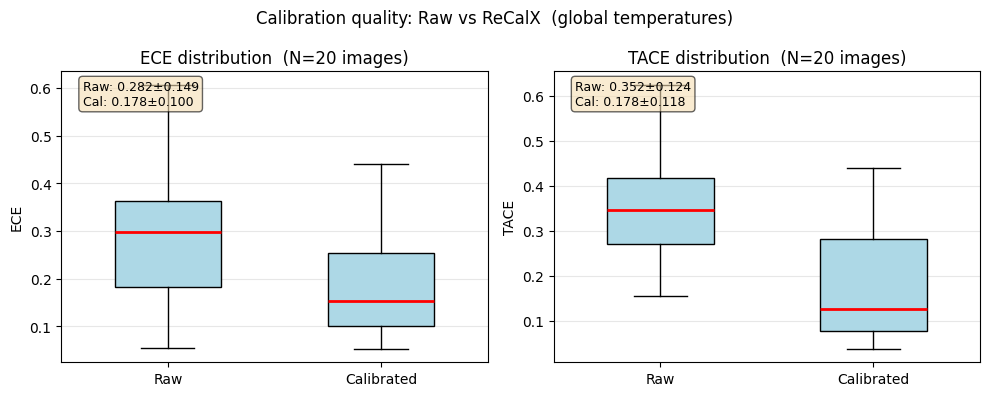

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (vals_raw, vals_cal, metric) in zip(axes, [
    (ece_raws,  ece_cals,  "ECE"),
    (tace_raws, tace_cals, "TACE"),
]):
    bplot = ax.boxplot(
        [vals_raw, vals_cal], labels=["Raw", "Calibrated"],
        patch_artist=True, widths=0.5,
        boxprops=dict(facecolor="lightblue"),
        medianprops=dict(color="red", linewidth=2),
    )
    ax.set_title(f"{metric} distribution  (N=20 images)")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)
    mr, sr = np.mean(vals_raw), np.std(vals_raw)
    mc, sc = np.mean(vals_cal), np.std(vals_cal)
    ax.text(0.05, 0.97,
            f"Raw: {mr:.3f}±{sr:.3f}\nCal: {mc:.3f}±{sc:.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

plt.suptitle("Calibration quality: Raw vs ReCalX  (global temperatures)", fontsize=12)
plt.tight_layout(); plt.show()

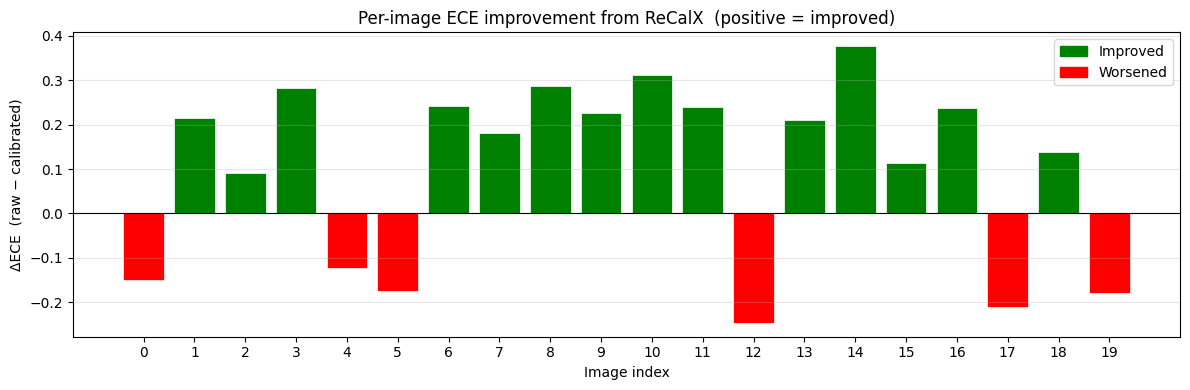

Improved: 14/20  |  Mean ΔECE: +0.1034


In [26]:
delta_ece = [r - c for r, c in zip(ece_raws, ece_cals)]   # positive = improvement
colors    = ["green" if d > 0 else "red" for d in delta_ece]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(delta_ece)), delta_ece, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Image index")
ax.set_ylabel("ΔECE  (raw − calibrated)")
ax.set_title("Per-image ECE improvement from ReCalX  (positive = improved)")
ax.set_xticks(range(len(delta_ece)))
ax.grid(axis="y", alpha=0.3)
ax.legend(handles=[
    mpatches.Patch(color="green", label="Improved"),
    mpatches.Patch(color="red",   label="Worsened"),
])
plt.tight_layout(); plt.show()

n_improved = sum(d > 0 for d in delta_ece)
print(f"Improved: {n_improved}/{len(delta_ece)}  |  Mean ΔECE: {np.mean(delta_ece):+.4f}")

## Section 4 — Normalization Sanity Check

Different attribution methods produce saliency maps with very different value ranges. The bucket generators are rank-based (scale-invariant), so they work regardless, but the raw scale differences explain why some methods look broken when visualised without normalization.

In [28]:
methods       = ["rise", "ig", "saliency", "gradientshap", "occlusion", "feature_ablation"]
method_labels = {"rise": "RISE", "ig": "IntegratedGradients",
                 "saliency": "Saliency", "gradientshap": "GradientShap",
                 "occlusion": "Occlusion", "feature_ablation": "FeatureAblation"}

saliency_maps = {}
for method in tqdm(methods, desc="Running attributions"):
    sal = pipeline.generate_map(single_tensor.to(device), target_class, method).cpu().numpy()
    saliency_maps[method] = sal

print(f"\n{'Method':<22} {'Raw min':>10} {'Raw max':>10} {'Norm min':>10} {'Norm max':>10}")
print("-" * 66)
for m, sal in saliency_maps.items():
    sal_n = normalize_saliency(sal)
    print(f"{method_labels[m]:<22} {sal.min():>10.4f} {sal.max():>10.4f} {sal_n.min():>10.4f} {sal_n.max():>10.4f}")

print("\nNote: BucketDeletionGenerator uses argsort → rank-invariant, scale does not matter.")

Running attributions: 100%|██████████| 4/4 [00:14<00:00,  3.65s/it]


Method                    Raw min    Raw max   Norm min   Norm max
------------------------------------------------------------------
RISE                       0.1843     1.2477     0.0000     1.0000
IntegratedGradients       -1.0137     1.1442     0.0000     1.0000
Saliency                   0.0003     0.7415     0.0000     1.0000
GradientShap              -1.3398     1.5222     0.0000     1.0000

Note: BucketDeletionGenerator uses argsort → rank-invariant, scale does not matter.


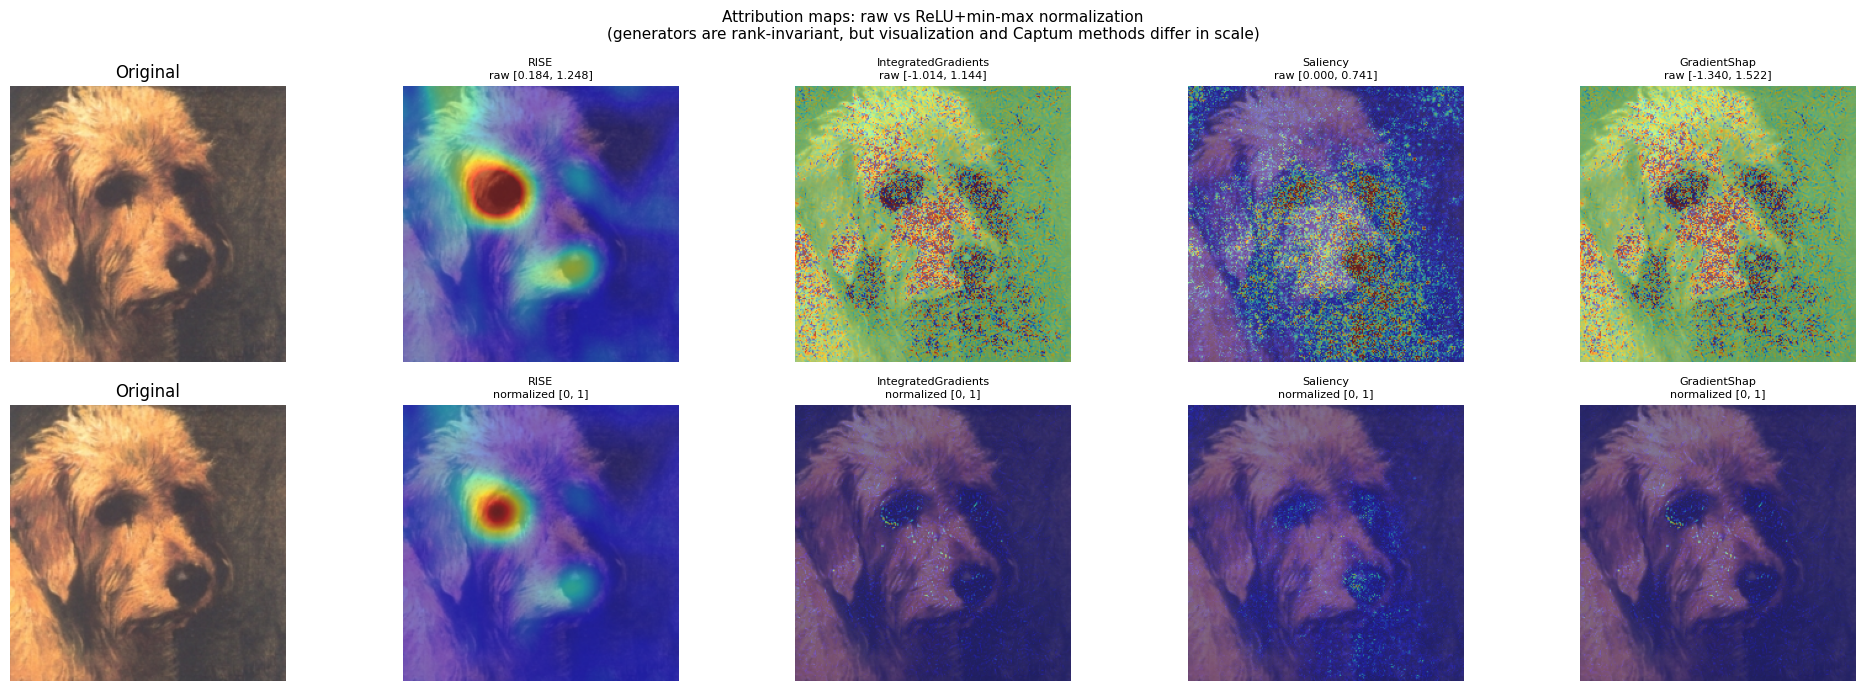

In [30]:
img_display = denormalize(single_tensor.detach())
n_methods   = len(methods)

fig, axes = plt.subplots(2, n_methods + 1, figsize=(4 * (n_methods + 1), 7))

for row in range(2):
    axes[row, 0].imshow(img_display)
    axes[row, 0].axis("off")
    axes[row, 0].set_title("Original")

for col, method in enumerate(methods, start=1):
    sal_raw  = saliency_maps[method]
    sal_norm = normalize_saliency(sal_raw)

    # Top row: raw (clipped for display, but shows real scale in title)
    sal_disp = np.clip(sal_raw, np.percentile(sal_raw, 2), np.percentile(sal_raw, 98))
    sal_disp = (sal_disp - sal_disp.min()) / (sal_disp.max() - sal_disp.min() + 1e-8)
    axes[0, col].imshow(img_display)
    axes[0, col].imshow(sal_disp, cmap="jet", alpha=0.5)
    axes[0, col].axis("off")
    axes[0, col].set_title(
        f"{method_labels[method]}\nraw [{sal_raw.min():.3f}, {sal_raw.max():.3f}]",
        fontsize=8
    )

    # Bottom row: normalized [0, 1]
    axes[1, col].imshow(img_display)
    axes[1, col].imshow(sal_norm, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")
    axes[1, col].set_title(f"{method_labels[method]}\nnormalized [0, 1]", fontsize=8)

axes[0, 0].set_ylabel("Raw (clipped display)", fontsize=9)
axes[1, 0].set_ylabel("Normalized [0, 1]", fontsize=9)
plt.suptitle(
    "Attribution maps: raw vs ReLU+min-max normalization\n"
    "(generators are rank-invariant, but visualization and Captum methods differ in scale)",
    fontsize=11
)
plt.tight_layout(); plt.show()

## Section 5 — Attribution Method Comparison

All six methods on ResNet50 + BucketDeletion(25), N=20 images.
Metrics: deletion AUC (map quality), ECE and TACE before/after calibration.

In [ ]:
METHODS_ALL   = ["rise", "ig", "saliency", "gradientshap", "occlusion", "feature_ablation"]
METHOD_LABELS = {
    "rise": "RISE", "ig": "IntGrad", "saliency": "Saliency",
    "gradientshap": "GradShap", "occlusion": "Occlusion", "feature_ablation": "FeatAblation",
}

# Reuse RISE maps already computed; compute the rest fresh
method_sals_all = {"rise": rise_sals}

for method in tqdm(METHODS_ALL[1:], desc="Saliency maps"):
    sals = []
    for i, (_, tensor) in enumerate(samples):
        sal = pipeline.generate_map(tensor.to(device), target_classes[i], method).cpu().numpy()
        sals.append(sal)
    method_sals_all[method] = sals
    print(f"  {method}: done")

print("All saliency maps ready.")

In [ ]:
gen_bkt25    = BucketDeletionGenerator(num_buckets=25)
method_results = {}

for method in tqdm(METHODS_ALL, desc="Methods"):
    sals_m = method_sals_all[method]

    # Pass 1: raw logits for calibration + cache raw probs
    m_logits_bins = {b: [] for b in range(NUM_BINS)}
    m_labels_bins = {b: [] for b in range(NUM_BINS)}
    raw_cache = []

    for i in range(len(samples)):
        tensor   = img_batch[i:i+1]
        tc       = target_classes[i]
        sal_t    = torch.from_numpy(normalize_saliency(sals_m[i]))
        seq, lvl = gen_bkt25(tensor.cpu(), sal_t)

        with torch.no_grad():
            step_logits = raw_model(seq.to(device)).cpu().numpy()

        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            m_logits_bins[b].append(logits)
            m_labels_bins[b].append(tc)

        _, raw_auc, raw_ap = evaluate_causal_metric(raw_model, seq.to(device), lvl, tc)
        raw_cache.append((raw_auc, raw_ap, tc, lvl))

    # Fit temperatures
    m_temps = [
        round(temperature_scaling(np.stack(m_logits_bins[b]),
              np.array(m_labels_bins[b], dtype=np.int64)), 4)
        if len(m_logits_bins[b]) > 1 else 1.0
        for b in range(NUM_BINS)
    ]
    m_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
    m_recalx.load_learned_temperatures(m_temps)

    # Pass 2: calibrated evaluation
    auc_l, ece_r, ece_c, tace_r, tace_c = [], [], [], [], []
    for i, (raw_auc, raw_ap, tc, lvl) in enumerate(raw_cache):
        tensor   = img_batch[i:i+1]
        sal_t    = torch.from_numpy(normalize_saliency(sals_m[i]))
        seq, lvl2 = gen_bkt25(tensor.cpu(), sal_t)
        labels_i = np.full(len(lvl), tc, dtype=np.int64)
        _, _, cal_ap = evaluate_causal_metric(m_recalx, seq.to(device), lvl2, tc)
        auc_l.append(raw_auc)
        ece_r.append(calculate_ece(raw_ap,   labels_i))
        ece_c.append(calculate_ece(cal_ap,   labels_i))
        tace_r.append(calculate_tace(raw_ap,  labels_i))
        tace_c.append(calculate_tace(cal_ap,  labels_i))

    method_results[method] = dict(auc=auc_l, ece_raw=ece_r, ece_cal=ece_c,
                                   tace_raw=tace_r, tace_cal=tace_c)
    print(f"  {METHOD_LABELS[method]:<14} "
          f"AUC {np.mean(auc_l):.3f}±{np.std(auc_l):.3f}  "
          f"ECE {np.mean(ece_r):.3f}→{np.mean(ece_c):.3f}")

In [ ]:
x        = np.arange(len(METHODS_ALL))
w        = 0.35
labels_x = [METHOD_LABELS[m] for m in METHODS_ALL]

def _m(key):  return [np.mean(method_results[m][key]) for m in METHODS_ALL]
def _s(key):  return [np.std(method_results[m][key])  for m in METHODS_ALL]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(x, _m("auc"), yerr=_s("auc"), color="steelblue", capsize=4, edgecolor="white")
axes[0].set_title("Deletion AUC  (higher = better saliency)")
axes[0].set_ylabel("AUC"); axes[0].set_ylim(0, 1)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_x, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.3)

for ax, metric in zip(axes[1:], ["ece", "tace"]):
    ax.bar(x - w/2, _m(f"{metric}_raw"), w, yerr=_s(f"{metric}_raw"),
           label="Raw",        color="steelblue",  capsize=4)
    ax.bar(x + w/2, _m(f"{metric}_cal"), w, yerr=_s(f"{metric}_cal"),
           label="Calibrated", color="darkorange", capsize=4)
    ax.set_title(f"{metric.upper()}: Raw vs Calibrated")
    ax.set_ylabel(metric.upper()); ax.legend()
    ax.set_xticks(x); ax.set_xticklabels(labels_x, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Attribution method comparison — ResNet50, BucketDeletion(25), N=20 images", fontsize=12)
plt.tight_layout(); plt.show()

# Summary table
print(f"{'Method':<18} {'AUC':>7} {'ECE_raw':>9} {'ECE_cal':>9} {'ΔECE':>8}")
print("-" * 55)
for m in METHODS_ALL:
    r = method_results[m]
    delta = np.mean(r['ece_cal']) - np.mean(r['ece_raw'])
    print(f"{METHOD_LABELS[m]:<18} {np.mean(r['auc']):>7.3f}"
          f" {np.mean(r['ece_raw']):>9.3f} {np.mean(r['ece_cal']):>9.3f} {delta:>+8.3f}")

## Section 6 — TopN(1%) vs Bucket(25) Deletion

TopN removes pixels in 1% increments (100 steps, fine-grained).
Bucket removes pixels in 25 equal-count groups (coarser, but aligned with calibration bins).
Using RISE saliency + ResNet50.

In [ ]:
# Single image: compare confidence curves
gen_topn   = TopNDeletionGenerator(step_fraction=0.01)   # 100 steps
gen_bkt25b = BucketDeletionGenerator(num_buckets=25)     # 25 steps

sal_t = torch.from_numpy(normalize_saliency(rise_sals[IMG_IDX]))

seq_topn,   lvl_topn   = gen_topn(single_tensor.cpu(),   sal_t)
seq_bucket, lvl_bucket = gen_bkt25b(single_tensor.cpu(), sal_t)

probs_topn,   auc_topn,   _ = evaluate_causal_metric(raw_model, seq_topn.to(device),   lvl_topn,   target_class)
probs_bucket, auc_bucket, _ = evaluate_causal_metric(raw_model, seq_bucket.to(device), lvl_bucket, target_class)

print(f"TopN(1%)   {len(lvl_topn):3d} steps  AUC={auc_topn:.4f}")
print(f"Bucket(25) {len(lvl_bucket):3d} steps  AUC={auc_bucket:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lvl_topn,   probs_topn,   color="steelblue",
        label=f"TopN 1%  (AUC={auc_topn:.3f},  {len(lvl_topn)} steps)")
ax.plot(lvl_bucket, probs_bucket, "o-", color="darkorange",
        label=f"Bucket 25  (AUC={auc_bucket:.3f}, {len(lvl_bucket)} steps)")
ax.set_xlabel("Fraction of pixels deleted")
ax.set_ylabel(f"P(class={target_class})")
ax.set_title(f"Confidence curve: TopN vs Bucket — Image {IMG_IDX}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Batch: calibrate both generators, compare ECE/TACE
gen_configs = {
    "TopN(1%)":   TopNDeletionGenerator(step_fraction=0.01),
    "Bucket(25)": BucketDeletionGenerator(num_buckets=25),
}
gen_results = {}

for gen_name, gen in gen_configs.items():
    g_logits_bins = {b: [] for b in range(NUM_BINS)}
    g_labels_bins = {b: [] for b in range(NUM_BINS)}

    for i in range(len(samples)):
        tensor   = img_batch[i:i+1]
        tc       = target_classes[i]
        sal_t    = torch.from_numpy(normalize_saliency(rise_sals[i]))
        seq, lvl = gen(tensor.cpu(), sal_t)
        with torch.no_grad():
            step_logits = raw_model(seq.to(device)).cpu().numpy()
        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            g_logits_bins[b].append(logits)
            g_labels_bins[b].append(tc)

    g_temps = [
        round(temperature_scaling(np.stack(g_logits_bins[b]),
              np.array(g_labels_bins[b], dtype=np.int64)), 4)
        if len(g_logits_bins[b]) > 1 else 1.0
        for b in range(NUM_BINS)
    ]
    print(f"{gen_name} samples/bin: {[len(g_logits_bins[b]) for b in range(NUM_BINS)]}")

    g_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
    g_recalx.load_learned_temperatures(g_temps)

    ece_r, ece_c, tace_r, tace_c = [], [], [], []
    for i in range(len(samples)):
        tensor   = img_batch[i:i+1]
        tc       = target_classes[i]
        sal_t    = torch.from_numpy(normalize_saliency(rise_sals[i]))
        seq, lvl = gen(tensor.cpu(), sal_t)
        labels_i = np.full(len(lvl), tc, dtype=np.int64)
        _, _, raw_ap = evaluate_causal_metric(raw_model,  seq.to(device), lvl, tc)
        _, _, cal_ap = evaluate_causal_metric(g_recalx,   seq.to(device), lvl, tc)
        ece_r.append(calculate_ece(raw_ap,   labels_i))
        ece_c.append(calculate_ece(cal_ap,   labels_i))
        tace_r.append(calculate_tace(raw_ap,  labels_i))
        tace_c.append(calculate_tace(cal_ap,  labels_i))

    gen_results[gen_name] = dict(ece_raw=ece_r, ece_cal=ece_c,
                                  tace_raw=tace_r, tace_cal=tace_c)
    print(f"  ECE  {np.mean(ece_r):.3f}±{np.std(ece_r):.3f} → {np.mean(ece_c):.3f}±{np.std(ece_c):.3f}")
    print(f"  TACE {np.mean(tace_r):.3f}±{np.std(tace_r):.3f} → {np.mean(tace_c):.3f}±{np.std(tace_c):.3f}")

In [ ]:
gen_names = list(gen_results.keys())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, metric in zip(axes, ["ece", "tace"]):
    data      = []
    tick_lbls = []
    for g in gen_names:
        data      += [gen_results[g][f"{metric}_raw"], gen_results[g][f"{metric}_cal"]]
        tick_lbls += [f"{g}\nRaw", f"{g}\nCal"]

    bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    face_colors = ["#aec7e8", "#ffbb78", "#c7c7c7", "#c49c94"]
    for patch, fc in zip(bp["boxes"], face_colors):
        patch.set_facecolor(fc)

    for pos, vals in enumerate(data, 1):
        ax.text(pos, np.mean(vals), f"{np.mean(vals):.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax.set_title(f"{metric.upper()}: Raw vs Calibrated")
    ax.set_ylabel(metric.upper()); ax.grid(axis="y", alpha=0.3)

plt.suptitle("TopN(1%) vs Bucket(25) — RISE saliency, ResNet50, N=20 images", fontsize=12)
plt.tight_layout(); plt.show()

## Section 7 — ViT-B/16 vs ResNet50

Load ViT-B/16 with its own RISE explainer (N=2000 masks for speed; use N=5000 for better saliency quality).
Same evaluation as Section 3: BucketDeletion(25), N=20 images.

In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
from src.RISE import RISE as SrcRISE

print("Loading ViT-B/16...")
vit_raw = vit_b_16(weights=ViT_B_16_Weights.DEFAULT).to(device).eval()
for p in vit_raw.parameters():
    p.requires_grad = False

# RISE for ViT — N=2000 is faster; raise to 5000 for publication-quality maps
print("Generating RISE masks for ViT...")
vit_rise = SrcRISE(vit_raw, (224, 224))
vit_rise.generate_masks(N=2000, s=10, p1=0.1)

with torch.no_grad():
    vit_target_classes = [
        int(torch.argmax(
            torch.softmax(vit_raw(t.to(device)), dim=1)
        ).item())
        for _, t in samples
    ]

n_agree = sum(a == b for a, b in zip(target_classes, vit_target_classes))
print(f"ResNet50 and ViT agree on {n_agree}/20 images top-1 class.")

In [ ]:
vit_rise_sals = []
for i, (_, tensor) in enumerate(tqdm(samples, desc="ViT RISE saliency")):
    with torch.no_grad():
        sal = vit_rise(tensor.cuda())[vit_target_classes[i]].cpu().numpy()
    vit_rise_sals.append(sal)

print("ViT RISE saliency shape:", np.array(vit_rise_sals).shape)

In [ ]:
gen_bkt25v = BucketDeletionGenerator(num_buckets=25)

vit_logits_bins = {b: [] for b in range(NUM_BINS)}
vit_labels_bins = {b: [] for b in range(NUM_BINS)}

for i in tqdm(range(len(samples)), desc="ViT logit collection"):
    tensor   = img_batch[i:i+1]
    tc       = vit_target_classes[i]
    sal_t    = torch.from_numpy(normalize_saliency(vit_rise_sals[i]))
    seq, lvl = gen_bkt25v(tensor.cpu(), sal_t)
    with torch.no_grad():
        step_logits = vit_raw(seq.to(device)).cpu().numpy()
    for step_idx, logits in enumerate(step_logits):
        b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
        vit_logits_bins[b].append(logits)
        vit_labels_bins[b].append(tc)

vit_temps = [
    round(temperature_scaling(np.stack(vit_logits_bins[b]),
          np.array(vit_labels_bins[b], dtype=np.int64)), 4)
    if len(vit_logits_bins[b]) > 1 else 1.0
    for b in range(NUM_BINS)
]
vit_recalx = ReCalXModel(vit_raw, num_bins=NUM_BINS).to(device)
vit_recalx.load_learned_temperatures(vit_temps)

vit_ece_raws, vit_ece_cals   = [], []
vit_tace_raws, vit_tace_cals = [], []

for i in tqdm(range(len(samples)), desc="ViT eval"):
    tensor   = img_batch[i:i+1]
    tc       = vit_target_classes[i]
    sal_t    = torch.from_numpy(normalize_saliency(vit_rise_sals[i]))
    seq, lvl = gen_bkt25v(tensor.cpu(), sal_t)
    labels_i = np.full(len(lvl), tc, dtype=np.int64)
    _, _, vit_raw_ap = evaluate_causal_metric(vit_raw,    seq.to(device), lvl, tc)
    _, _, vit_cal_ap = evaluate_causal_metric(vit_recalx, seq.to(device), lvl, tc)
    vit_ece_raws.append(calculate_ece(vit_raw_ap,   labels_i))
    vit_ece_cals.append(calculate_ece(vit_cal_ap,   labels_i))
    vit_tace_raws.append(calculate_tace(vit_raw_ap,  labels_i))
    vit_tace_cals.append(calculate_tace(vit_cal_ap,  labels_i))

print(f"ViT  ECE  raw={np.mean(vit_ece_raws):.4f}±{np.std(vit_ece_raws):.4f}  cal={np.mean(vit_ece_cals):.4f}±{np.std(vit_ece_cals):.4f}")
print(f"ViT  TACE raw={np.mean(vit_tace_raws):.4f}±{np.std(vit_tace_raws):.4f}  cal={np.mean(vit_tace_cals):.4f}±{np.std(vit_tace_cals):.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_groups = {
    "ECE":  [ece_raws,     ece_cals,     vit_ece_raws,  vit_ece_cals],
    "TACE": [tace_raws,    tace_cals,    vit_tace_raws, vit_tace_cals],
}
tick_lbls = ["ResNet50\nRaw", "ResNet50\nCal", "ViT-B/16\nRaw", "ViT-B/16\nCal"]
face_colors = ["#aec7e8", "#ffbb78", "#c5b0d5", "#dbdb8d"]

for ax, (metric, data) in zip(axes, data_groups.items()):
    bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, fc in zip(bp["boxes"], face_colors):
        patch.set_facecolor(fc)
    for pos, vals in enumerate(data, 1):
        ax.text(pos, np.mean(vals), f"{np.mean(vals):.3f}±{np.std(vals):.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{metric}: ResNet50 vs ViT-B/16")
    ax.set_ylabel(metric); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Model comparison — RISE saliency, BucketDeletion(25), N=20 images", fontsize=12)
plt.tight_layout(); plt.show()

# Temperature profile comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_x = np.arange(NUM_BINS)
for ax, (model_name, temps) in zip(axes, [("ResNet50", batch_temps), ("ViT-B/16", vit_temps)]):
    ax.bar(bins_x, temps, color="steelblue", edgecolor="white")
    ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1")
    ax.set_xlabel("Perturbation bin"); ax.set_ylabel("Temperature T")
    ax.set_title(f"Fitted temperatures — {model_name}")
    ax.set_xticks(bins_x)
    ax.set_xticklabels([f"{b/NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.suptitle("Temperature profiles: ResNet50 vs ViT-B/16", fontsize=12)
plt.tight_layout(); plt.show()